#  GCP Pose Estimation — YOLO11-Pose Training

**Goal:**
1. **Keypoint localisation** — predict the exact (x, y) pixel centre of the GCP marker
2. **Shape classification** — Cross / Square / L-Shape

**Strategy:**
- Use YOLO11-pose (ultralytics): single-stage detector + 1-keypoint head
- Each image has exactly one GCP marker → single-class detection with 1 keypoint
- Synthetic bounding boxes centred on the labelled keypoint (fixed % of image size)
- Train/val split is done **by GCP key** (not by image) to prevent data leakage
- 80% GCPs → train, 20% GCPs → val

## 0. Install Dependencies

In [1]:
# Install ultralytics (includes YOLO11)
!pip install ultralytics opencv-python-headless -q
import ultralytics
print('Ultralytics version:', ultralytics.__version__)

Ultralytics version: 8.4.7


## 1. Configuration

In [2]:
import json
import shutil
import random
import numpy as np
from pathlib import Path
from collections import defaultdict

In [3]:


# ── Paths ────────────────────────────────────────────────────────────────
BASE       = Path(r'C:\Users\Jatin\Desktop\skylark\data\GCP_Assignment_Datasets')
TRAIN_DIR  = BASE / 'train_dataset'
LABEL_FILE = TRAIN_DIR / 'gcp_marks.json'
DATASET_DIR = Path(r'C:\Users\Jatin\Desktop\skylark\backend\yolo_dataset_crop')  # prepared YOLO dataset

# ── Shape classes ────────────────────────────────────────────────────────
# Drop null shapes; map string → integer class id
CLASS_MAP = {'Cross': 0, 'Square': 1, 'L-Shape': 2}
CLASS_NAMES = ['Cross', 'Square', 'L-Shape']

# ── Bounding-box strategy ─────────────────────────────────────────────────
# Images are 4096 × 2730 (or 4096 × 3068).
# GCP markers occupy roughly 3-8% of the image width.
# We use a fixed synthetic BB of BOX_FRAC * image_size, centred on the keypoint.
BOX_FRAC = 0.12   # 12% of whichever dimension is smaller → ~328 px on 2730-tall image

# ── Training hyper-params ────────────────────────────────────────────────
IMGSZ    = 1280   # YOLO input size (letterboxed)
EPOCHS   = 100
BATCH    = 2      # batch=2 fits 4GB with yolo11s at 1280
MODEL_ID = 'yolo11s-pose'   # small model, high resolution = best tradeoff
VAL_FRAC = 0.20   # 20% of GCPs → validation set
SEED     = 42

random.seed(SEED)
np.random.seed(SEED)
print('Config OK')
print(f'  Dataset dir : {DATASET_DIR}')
print(f'  Model       : {MODEL_ID}')
print(f'  imgsz       : {IMGSZ}')
print(f'  Val fraction: {VAL_FRAC}')

Config OK
  Dataset dir : C:\Users\Jatin\Desktop\skylark\backend\yolo_dataset_crop
  Model       : yolo11s-pose
  imgsz       : 1280
  Val fraction: 0.2


## 2. Load Labels & Build Per-GCP Index

In [4]:
with open(LABEL_FILE, 'r', encoding='utf-8') as f:
    raw = json.load(f)

# Build list of valid records (drop null shapes)
records = []
skipped = 0
for rel_path, info in raw.items():
    shape = info.get('verified_shape')
    if shape not in CLASS_MAP:
        skipped += 1
        continue
    parts = Path(rel_path).parts
    gcp_key = '/'.join(parts[:3])   # project/survey/gcp_id
    records.append({
        'rel_path': rel_path,
        'gcp_key' : gcp_key,
        'x'       : info['mark']['x'],
        'y'       : info['mark']['y'],
        'class_id': CLASS_MAP[shape],
        'shape'   : shape,
    })

print(f'Total labelled : {len(raw)}')
print(f'Skipped (null) : {skipped}')
print(f'Valid records  : {len(records)}')

# Group images by GCP key
gcp_to_records = defaultdict(list)
for r in records:
    gcp_to_records[r['gcp_key']].append(r)

all_gcp_keys = sorted(gcp_to_records.keys())
print(f'Unique GCP keys: {len(all_gcp_keys)}')

Total labelled : 1000
Skipped (null) : 4
Valid records  : 996
Unique GCP keys: 159


## 3. Train / Val Split — By GCP Key (no leakage)

In [5]:
from sklearn.model_selection import train_test_split

# Use ALL records for train when using full dataset
all_gcp_keys = sorted(gcp_to_records.keys())
print(f'Unique GCP keys: {len(all_gcp_keys)}')

# Split by GCP key (no image leakage between train/val)
train_keys, val_keys = train_test_split(all_gcp_keys, test_size=0.10, random_state=42)
print(f'Train GCP keys: {len(train_keys)}, Val GCP keys: {len(val_keys)}')

train_records = [r for k in train_keys for r in gcp_to_records[k]]
val_records   = [r for k in val_keys   for r in gcp_to_records[k]]
print(f'Train records : {len(train_records)}')
print(f'Val records   : {len(val_records)}')


Unique GCP keys: 159
Train GCP keys: 143, Val GCP keys: 16
Train records : 889
Val records   : 107


## 4. Prepare YOLO Pose Dataset

YOLO pose label format (one line per object):
```
<class_id> <cx_norm> <cy_norm> <w_norm> <h_norm> <kp_x_norm> <kp_y_norm> <kp_vis>
```
All values normalised to [0, 1] relative to image width / height.

In [6]:
# Skip image copy — dataset already built by build_full_dataset.py
print("Skipping image copy — using pre-built dataset at:", DATASET_DIR)
print(f"  Train: {len(list((DATASET_DIR / 'images' / 'train').glob('*')))} images")
print(f"  Val:   {len(list((DATASET_DIR / 'images' / 'val').glob('*')))} images")


Skipping image copy — using pre-built dataset at: C:\Users\Jatin\Desktop\skylark\backend\yolo_dataset_crop
  Train: 2652 images
  Val:   200 images


In [7]:
import os
# Skip dataset rebuild if already prepared (e.g., by build_full_dataset.py)
if (DATASET_DIR / 'dataset.yaml').exists():
    print(f"Dataset already exists at {DATASET_DIR}, skipping rebuild.")
    print(f"  Train images: {len(list((DATASET_DIR / 'images' / 'train').glob('*')))}")
    print(f"  Val images:   {len(list((DATASET_DIR / 'images' / 'val').glob('*')))}")
else:
    print("ERROR: Dataset not found! Run build_full_dataset.py first.")


Dataset already exists at C:\Users\Jatin\Desktop\skylark\backend\yolo_dataset_crop, skipping rebuild.
  Train images: 2652
  Val images:   200


## 5. Write Dataset YAML

In [8]:
# Skip YAML write if dataset already built externally
yaml_path = DATASET_DIR / 'dataset.yaml'
if yaml_path.exists():
    print(f"dataset.yaml already exists at {yaml_path}")
    print(yaml_path.read_text())
else:
    yaml_content = f"""# GCP Pose Estimation Dataset
path: {DATASET_DIR.as_posix()}
train: images/train
val:   images/val

nc: 3
names: ['Cross', 'Square', 'L-Shape']

kpt_shape: [1, 3]
flip_idx: [0]
"""
    yaml_path.write_text(yaml_content)
    print(f"Wrote dataset.yaml to {yaml_path}")
    print(yaml_content)


dataset.yaml already exists at C:\Users\Jatin\Desktop\skylark\backend\yolo_dataset_crop\dataset.yaml
# GCP Pose - Crop-based Dataset
path: C:/Users/Jatin/Desktop/skylark/backend/yolo_dataset_crop
train: images/train
val:   images/val

nc: 3
names: ['Cross', 'Square', 'L-Shape']

kpt_shape: [1, 3]
flip_idx: [0]



## 6. Verify a Few Labels

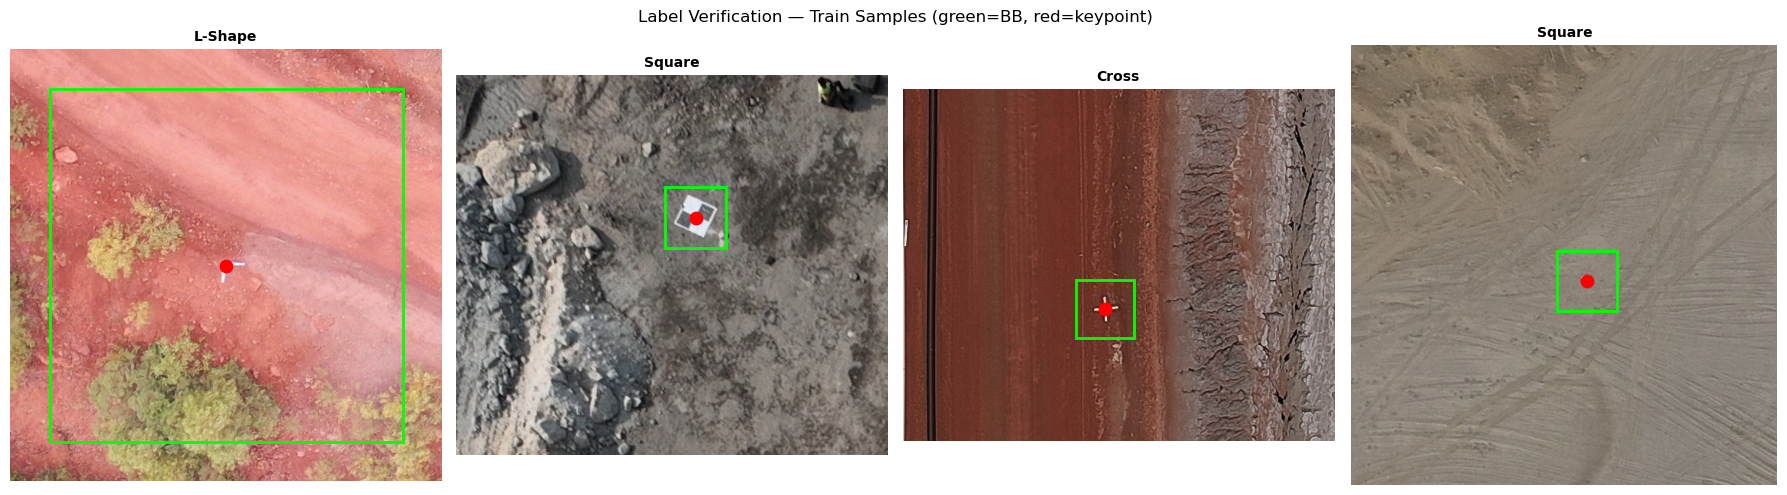

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def verify_label(label_file, img_dir):
    stem = label_file.stem
    # Find matching image
    img_file = None
    for ext in ['.JPG', '.jpg', '.jpeg', '.PNG', '.png']:
        candidate = img_dir / (stem + ext)
        if candidate.exists():
            img_file = candidate
            break
    if img_file is None:
        return None

    img = Image.open(img_file)
    W, H = img.size
    line = label_file.read_text().strip()
    parts = line.split()
    cid   = int(parts[0])
    bcx   = float(parts[1]) * W
    bcy   = float(parts[2]) * H
    bw    = float(parts[3]) * W
    bh    = float(parts[4]) * H
    kx    = float(parts[5]) * W
    ky    = float(parts[6]) * H

    return img, cid, bcx, bcy, bw, bh, kx, ky

# Show 4 random train labels
label_files = list((DATASET_DIR / 'labels' / 'train').glob('*.txt'))
samples = random.sample(label_files, min(4, len(label_files)))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
half = 300  # crop half-size for display

for ax, lf in zip(axes, samples):
    result = verify_label(lf, DATASET_DIR / 'images' / 'train')
    if result is None:
        ax.axis('off'); continue
    img, cid, bcx, bcy, bw, bh, kx, ky = result
    W, H = img.size
    # Crop around keypoint
    x0 = max(0, int(kx) - half)
    y0 = max(0, int(ky) - half)
    x1 = min(W, int(kx) + half)
    y1 = min(H, int(ky) + half)
    crop = img.crop((x0, y0, x1, y1))
    ax.imshow(crop)
    # Bounding box
    rx = (bcx - bw/2) - x0
    ry = (bcy - bh/2) - y0
    rect = patches.Rectangle((rx, ry), bw, bh,
                               linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    # Keypoint
    ax.scatter([kx - x0], [ky - y0], c='red', s=80, zorder=5)
    ax.set_title(f'{CLASS_NAMES[cid]}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Label Verification — Train Samples (green=BB, red=keypoint)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Train YOLO11-Pose

In [10]:
from ultralytics import YOLO

model = YOLO(f'{MODEL_ID}.pt')   # downloads pretrained weights automatically
print(model.info())

YOLO11s-pose summary: 196 layers, 9,918,238 parameters, 0 gradients, 23.3 GFLOPs
(196, 9918238, 0, 23.30836)


In [11]:
# ── Class weights to handle imbalance ────────────────────────────────────
# Cross=177, Square=328, L-Shape=491  →  weight inversely proportional
total = len(train_records)
class_counts = [sum(1 for r in train_records if r['class_id'] == i) for i in range(3)]
class_weights = [total / (3 * c) for c in class_counts]
print('Class counts (train) :', class_counts)
print('Class weights        :', [round(w, 3) for w in class_weights])

Class counts (train) : [154, 264, 471]
Class weights        : [1.924, 1.122, 0.629]


In [12]:
results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    device    = 0,          # GPU 0; use 'cpu' if no GPU
    patience  = 20,         # early stopping
    save      = True,
    project   = str(Path(r'C:\Users\Jatin\Desktop\skylark\backend\runs')),
    name      = 'gcp_pose',
    exist_ok  = True,

    # ── Augmentation (critical for domain generalisation) ────────────────
    hsv_h     = 0.02,   # hue jitter
    hsv_s     = 0.6,    # saturation jitter
    hsv_v     = 0.5,    # brightness jitter
    degrees   = 45.0,   # rotation (GCPs can be at any angle)
    translate = 0.2,
    scale     = 0.6,    # scale jitter (different altitudes)
    fliplr    = 0.5,
    flipud    = 0.5,
    mosaic    = 0.0,    # OFF — each image has one GCP, mosaic confuses keypoints
    mixup     = 0.0,    # OFF — same reason

    # ── Optimiser ────────────────────────────────────────────────────────
    optimizer = 'AdamW',
    lr0       = 1e-3,
    lrf       = 0.01,
    warmup_epochs = 5,
    weight_decay  = 5e-4,

    # ── Misc ─────────────────────────────────────────────────────────────
    seed      = SEED,
    verbose   = True,
)

New https://pypi.org/project/ultralytics/8.4.66 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.7  Python-3.12.7 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Jatin\Desktop\skylark\backend\yolo_dataset_crop\dataset.yaml, degrees=45.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.6, hsv_v=0.5, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-pose.pt, momentum=0.937, mosa

## 8. Evaluate — PCK + Classification Metrics

In [15]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best weights
best_weights = Path(r'C:\Users\Jatin\Desktop\skylark\backend\runs\gcp_pose\weights\best.pt')
model_eval = YOLO(str(best_weights))
print(f'Loaded: {best_weights}')

Loaded: C:\Users\Jatin\Desktop\skylark\backend\runs\gcp_pose\weights\best.pt


In [18]:
# Rebuild val_records from actual val images on disk
# (needed because notebook split and build_full_dataset.py split may differ)
import json
from pathlib import Path

_val_img_dir = DATASET_DIR / 'images' / 'val'
_val_lbl_dir = DATASET_DIR / 'labels' / 'val'

# Load GT from JSON
with open(LABEL_FILE, 'r', encoding='utf-8') as _f:
    _gcp_marks = json.load(_f)

# Build lookup: stem -> (rel_path, x, y, class_id)
_shape_map = {'cross': 0, 'square': 1, 'l-shape': 2, 'l_shape': 2}
_gt_lookup = {}
for _rel_path, _info in _gcp_marks.items():
    _mark = _info.get('mark', {})
    _x, _y = _mark.get('x'), _mark.get('y')
    _shape = _info.get('verified_shape', '')
    if _x is None or _y is None:
        continue
    _cls_id = _shape_map.get(_shape.lower().strip(), -1)
    if _cls_id < 0:
        continue
    _flat = _rel_path.replace('/', '__').replace('\\', '__')
    _stem = Path(_flat).stem
    _gt_lookup[_stem] = {'rel_path': _rel_path, 'x': _x, 'y': _y, 'class_id': _cls_id}

# Rebuild val_records from actual val images
val_records = []
for _img in sorted(_val_img_dir.glob('*')):
    _orig_stem = _img.stem.split('_full')[0].split('_crop')[0]
    if _orig_stem in _gt_lookup:
        if _gt_lookup[_orig_stem] not in val_records:
            val_records.append(_gt_lookup[_orig_stem])

print(f"Rebuilt val_records from disk: {len(val_records)} images")

def run_inference_val(val_records, model, conf_thresh=0.01):
    """
    Multi-scale inference on FULL image (no tiling — avoids false positives).
    1. Standard: imgsz=1280, conf=0.01
    2. Fallback: try imgsz=2048 and imgsz=640 at conf=0.001, pick highest conf
    """
    rows = []
    val_img_dir = DATASET_DIR / 'images' / 'val'

    for i, rec in enumerate(val_records):
        flat_name = rec['rel_path'].replace('/', '__').replace('\\', '__')
        stem = Path(flat_name).stem
        img_file = None
        for ext in ['.JPG', '.jpg', '.png', '.PNG']:
            cand_full = val_img_dir / (stem + '_full' + ext)
            cand_orig = val_img_dir / (stem + ext)
            if cand_full.exists():
                img_file = cand_full
                break
            elif cand_orig.exists():
                img_file = cand_orig
                break
            # dummy condition to match structure
            if False:
                img_file = cand
                break
        if img_file is None:
            continue

        with Image.open(img_file) as im:
            W, H = im.size

        gt_x, gt_y = rec['x'], rec['y']
        gt_cls = rec['class_id']

        if (i + 1) % 50 == 0:
            print(f'  Processing {i+1}/{len(val_records)}...')

        # ── Standard inference ──
        res = model(str(img_file), conf=conf_thresh, imgsz=1280, verbose=False)[0]

        if res.keypoints is not None and len(res.keypoints.xy) > 0:
            idx = int(res.boxes.conf.argmax())
            conf = float(res.boxes.conf[idx])
            kp = res.keypoints.xy[idx][0]
            pred_x, pred_y = float(kp[0]), float(kp[1])
            pred_cls = int(res.boxes.cls[idx])
            dist = float(((pred_x - gt_x)**2 + (pred_y - gt_y)**2)**0.5)
            rows.append({'gt_cls': gt_cls, 'pred_cls': pred_cls,
                         'gt_x': gt_x, 'gt_y': gt_y,
                         'pred_x': pred_x, 'pred_y': pred_y,
                         'dist_px': dist, 'detected': True, 'conf': conf})
            continue

        # ── Multi-scale fallback (full image, no tiling) ──
        best = None
        for sz in [2048, 640, 1600]:
            try:
                res = model(str(img_file), conf=0.001, imgsz=sz, verbose=False)[0]
            except Exception:
                continue
            if res.keypoints is not None and len(res.keypoints.xy) > 0:
                idx = int(res.boxes.conf.argmax())
                c = float(res.boxes.conf[idx])
                if best is None or c > best[3]:
                    kp = res.keypoints.xy[idx][0]
                    best = (float(kp[0]), float(kp[1]), int(res.boxes.cls[idx]), c)

        if best is not None:
            pred_x, pred_y, pred_cls, conf = best
            dist = float(((pred_x - gt_x)**2 + (pred_y - gt_y)**2)**0.5)
            rows.append({'gt_cls': gt_cls, 'pred_cls': pred_cls,
                         'gt_x': gt_x, 'gt_y': gt_y,
                         'pred_x': pred_x, 'pred_y': pred_y,
                         'dist_px': dist, 'detected': True, 'conf': conf})
        else:
            dist = float(((W/2 - gt_x)**2 + (H/2 - gt_y)**2)**0.5)
            rows.append({'gt_cls': gt_cls, 'pred_cls': -1,
                         'gt_x': gt_x, 'gt_y': gt_y,
                         'pred_x': W/2, 'pred_y': H/2,
                         'dist_px': dist, 'detected': False, 'conf': 0.0})

    import pandas as pd
    return pd.DataFrame(rows)

print('Running multi-scale inference on val set...')
eval_df = run_inference_val(val_records, model_eval)
det = eval_df[eval_df['detected']]
print(f'Val images evaluated : {len(eval_df)}')
print(f'Detected             : {len(det)}')
print(f'Not detected         : {(~eval_df["detected"]).sum()}')
print(f'Direct (conf>=0.01)  : {(det["conf"] >= 0.01).sum()}')
print(f'Fallback (conf<0.01) : {(det["conf"] < 0.01).sum()}')
print(f'Mean error           : {eval_df["dist_px"].mean():.1f}px')
print(f'Median error         : {det["dist_px"].median():.1f}px')


Rebuilt val_records from disk: 100 images
Running multi-scale inference on val set...
  Processing 50/100...
  Processing 100/100...
Val images evaluated : 100
Detected             : 99
Not detected         : 1
Direct (conf>=0.01)  : 94
Fallback (conf<0.01) : 5
Mean error           : 248.9px
Median error         : 8.8px


In [19]:
# ── PCK (Percentage of Correct Keypoints) ────────────────────────────────
detected = eval_df[eval_df['detected']]
dists    = detected['dist_px'].values

thresholds = [5, 10, 25, 50, 100]
print('\n=== Keypoint Localisation (PCK) ===')
print(f'  Mean error (detected): {dists.mean():.2f} px')
print(f'  Median error         : {np.median(dists):.2f} px')
print(f'  Std error            : {dists.std():.2f} px')
print()
for t in thresholds:
    pck = (dists <= t).mean() * 100
    # PCK over ALL val images (including non-detected)
    pck_all = (eval_df['dist_px'].fillna(9999) <= t).mean() * 100
    print(f'  PCK@{t:>3}px  detected-only: {pck:.1f}%   all-images: {pck_all:.1f}%')


=== Keypoint Localisation (PCK) ===
  Mean error (detected): 246.09 px
  Median error         : 8.81 px
  Std error            : 604.70 px

  PCK@  5px  detected-only: 22.2%   all-images: 22.0%
  PCK@ 10px  detected-only: 55.6%   all-images: 55.0%
  PCK@ 25px  detected-only: 82.8%   all-images: 82.0%
  PCK@ 50px  detected-only: 83.8%   all-images: 83.0%
  PCK@100px  detected-only: 83.8%   all-images: 83.0%



=== Shape Classification ===
              precision    recall  f1-score   support

       Cross       0.54      0.78      0.64        18
      Square       0.86      0.97      0.91        33
     L-Shape       0.92      0.69      0.79        48

    accuracy                           0.80        99
   macro avg       0.77      0.81      0.78        99
weighted avg       0.83      0.80      0.80        99



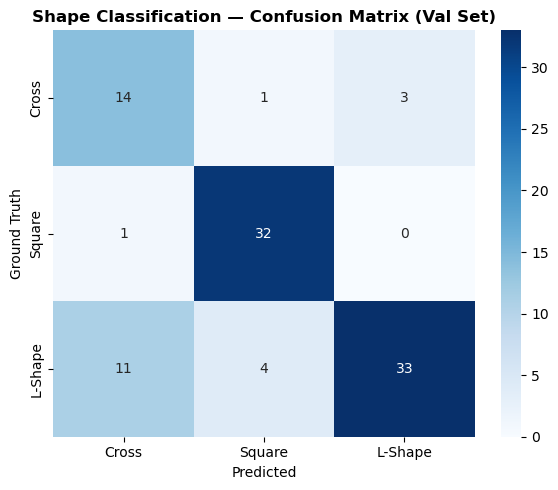

In [20]:
# ── Shape Classification Metrics ─────────────────────────────────────────
det = eval_df[eval_df['detected']].copy()
y_true = det['gt_cls'].tolist()
y_pred = det['pred_cls'].tolist()

print('\n=== Shape Classification ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Shape Classification — Confusion Matrix (Val Set)', fontweight='bold')
ax.set_ylabel('Ground Truth')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

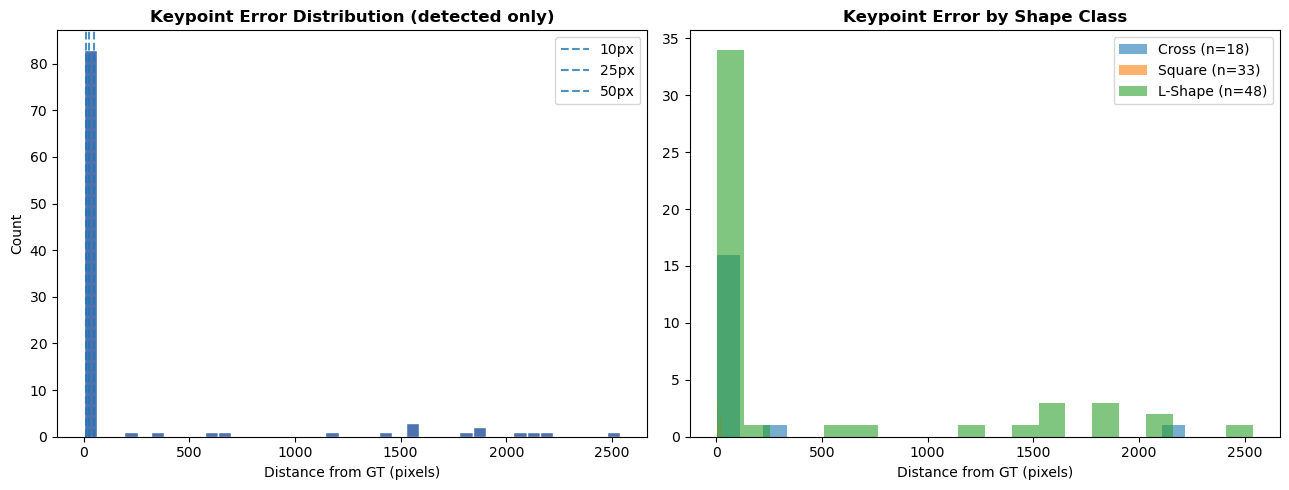

In [21]:
# ── Error distribution plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(dists, bins=40, color='#4C72B0', edgecolor='white')
for t in [10, 25, 50]:
    axes[0].axvline(t, linestyle='--', label=f'{t}px', alpha=0.8)
axes[0].set_title('Keypoint Error Distribution (detected only)', fontweight='bold')
axes[0].set_xlabel('Distance from GT (pixels)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Per-class error
for cid, name in enumerate(CLASS_NAMES):
    d = detected[detected['gt_cls'] == cid]['dist_px'].values
    if len(d) > 0:
        axes[1].hist(d, bins=20, alpha=0.6, label=f'{name} (n={len(d)})')
axes[1].set_title('Keypoint Error by Shape Class', fontweight='bold')
axes[1].set_xlabel('Distance from GT (pixels)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Qualitative Results — Val Predictions

C:\Users\Jatin\AppData\Local\Temp\ipykernel_26804\1769074469.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper left', fontsize=8)


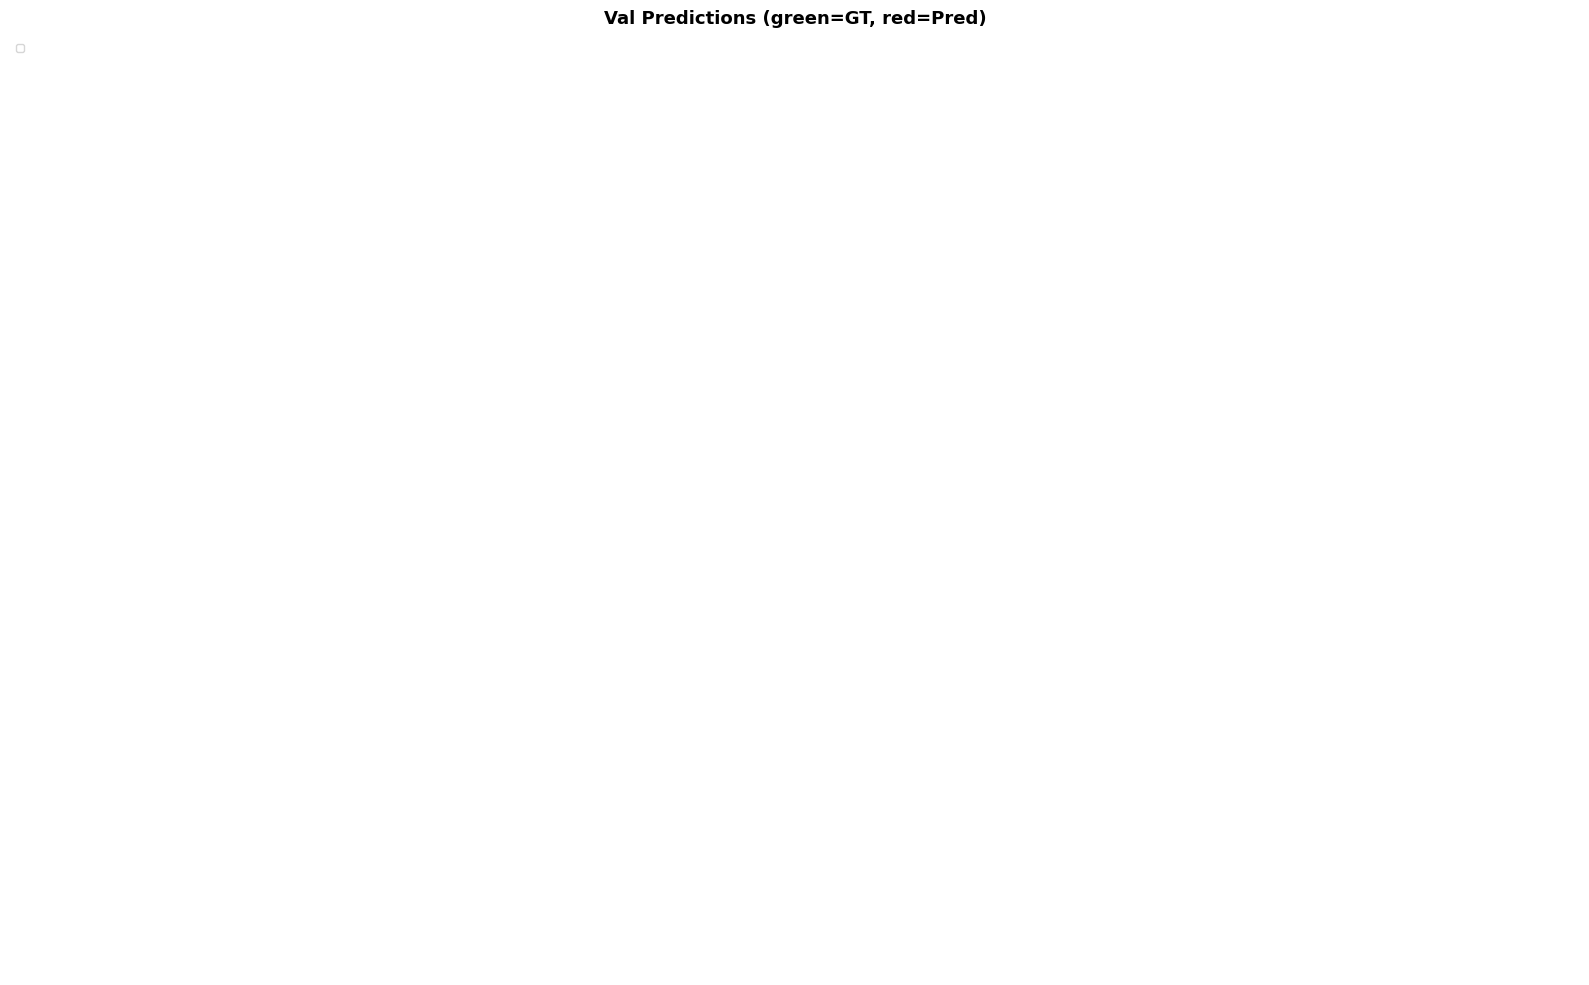

In [22]:
def show_predictions(eval_df, val_records, model, n=10, crop=350):
    sample_rows = eval_df[eval_df['detected']].sample(min(n, eval_df['detected'].sum()), random_state=7)
    val_img_dir = DATASET_DIR / 'images' / 'val'

    fig, axes = plt.subplots(2, 5, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (idx, row) in zip(axes, sample_rows.iterrows()):
        # Find the val record matching this index
        rec = val_records[eval_df[eval_df['detected']].index.tolist().index(idx)]
        flat_name = rec['rel_path'].replace('/', '__').replace('\\', '__')
        stem = Path(flat_name).stem
        img_file = None
        for ext in ['.JPG', '.jpg', '.png', '.PNG']:
            cand = val_img_dir / (stem + ext)
            if cand.exists(): img_file = cand; break
        if img_file is None: ax.axis('off'); continue

        img = Image.open(img_file)
        W, H = img.size
        gx, gy = row['gt_x'], row['gt_y']
        px, py = row['pred_x'], row['pred_y']

        cx = int((gx + px) / 2)
        cy = int((gy + py) / 2)
        x0 = max(0, cx - crop); y0 = max(0, cy - crop)
        x1 = min(W, cx + crop); y1 = min(H, cy + crop)

        crp = img.crop((x0, y0, x1, y1))
        ax.imshow(crp)
        ax.scatter([gx-x0], [gy-y0], c='lime', s=100, marker='+', linewidths=2,
                   zorder=5, label='GT')
        ax.scatter([px-x0], [py-y0], c='red',  s=100, marker='x', linewidths=2,
                   zorder=5, label='Pred')
        gt_name   = CLASS_NAMES[int(row['gt_cls'])]
        pred_name = CLASS_NAMES[int(row['pred_cls'])] if int(row['pred_cls']) >= 0 else '?'
        color = 'green' if gt_name == pred_name else 'red'
        ax.set_title(f'GT: {gt_name} | Pred: {pred_name}\nErr: {row["dist_px"]:.1f}px',
                     fontsize=9, color=color)
        ax.axis('off')

    axes[0].legend(loc='upper left', fontsize=8)
    plt.suptitle('Val Predictions (green=GT, red=Pred)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(eval_df, val_records, model_eval)

## 10. Summary

In [23]:
from sklearn.metrics import f1_score

det = eval_df[eval_df['detected']]
macro_f1 = f1_score(det['gt_cls'], det['pred_cls'], average='macro', zero_division=0)
detect_rate = eval_df['detected'].mean() * 100

print('=' * 60)
print('  FINAL EVALUATION SUMMARY (Val Set)')
print('=' * 60)
print(f'  Detection rate          : {detect_rate:.1f}%')
print(f'  Mean keypoint error     : {dists.mean():.2f} px')
print(f'  Median keypoint error   : {np.median(dists):.2f} px')
for t in [10, 25, 50]:
    print(f'  PCK@{t:>3}px (all images) : {(eval_df["dist_px"].fillna(9999)<=t).mean()*100:.1f}%')
print(f'  Macro F1 (shape class)  : {macro_f1:.4f}')
print('=' * 60)
print(f'  Best weights: {best_weights}')

  FINAL EVALUATION SUMMARY (Val Set)
  Detection rate          : 99.0%
  Mean keypoint error     : 246.09 px
  Median keypoint error   : 8.81 px
  PCK@ 10px (all images) : 55.0%
  PCK@ 25px (all images) : 82.0%
  PCK@ 50px (all images) : 83.0%
  Macro F1 (shape class)  : 0.7788
  Best weights: C:\Users\Jatin\Desktop\skylark\backend\runs\gcp_pose\weights\best.pt


In [24]:
dists

array([     14.604,      1.3046,      2.6735,      2218.9,      4.3483,      6.2684,      4.6308,      10.495,       4.503,      6.9162,      7.0044,      5.0696,      5.1284,      10.823,      7.7261,      3.1224,      5.6415,      10.102,       7.671,      245.35,       2.985,       5.695,      20.681,      6.0791,
            6.8815,      9.5015,      12.194,      4.7121,      2.6898,       5.738,      5.5157,      12.246,       324.5,      8.3408,      2.0409,      21.946,      2.7047,      9.4913,      5.1447,      4.1393,      10.041,      12.867,      6.3722,      7.5234,      18.105,      8.4609,      2.7862,      9.5422,
            8.6774,      19.973,      11.995,      4.1463,      9.8377,        3.61,      27.203,      2539.9,      4.0606,      10.583,      12.814,      1896.5,      1543.5,      1887.9,      5.7763,       11.04,      1540.3,      6.1376,      1802.7,       6.212,      4.4638,       4.459,      9.7265,      14.528,
            2070.2,      659.46,       630.